# Pneumonia Detection via Chest Radiography: DenseNet121 Transfer Learning
This notebook implements an end-to-end deep learning pipeline to detect pneumonia in chest X-rays. It utilises a pre-trained **DenseNet121** architecture, domain-aware data augmentation, algorithmic class balancing, and a two-stage fine-tuning strategy to achieve high sensitivity and specificity.
> Add blockquote



In [ ]:
import kagglehub
import os

# 1. Download dataset
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Base path:", path)

# 2. Define global paths
# Kagglehub structure is usually: path/chest_xray/train
base_dir = os.path.join(path, 'chest_xray')

# Check if the 'chest_xray' folder exists inside the path
if not os.path.exists(base_dir):
    base_dir = path

TRAIN_DIR = os.path.join(base_dir, 'train')
TEST_DIR = os.path.join(base_dir, 'test')
VAL_DIR = os.path.join(base_dir, 'val')

print(f"Train Path: {TRAIN_DIR}")
print(f"Test Path: {TEST_DIR}")

Base path: C:\Users\Dell\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2
Train Path: C:\Users\Dell\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2\chest_xray\train
Test Path: C:\Users\Dell\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2\chest_xray\test


Path Configuration and loading images to view

Image shape: (1476, 1956)
Image shape: (976, 1448)


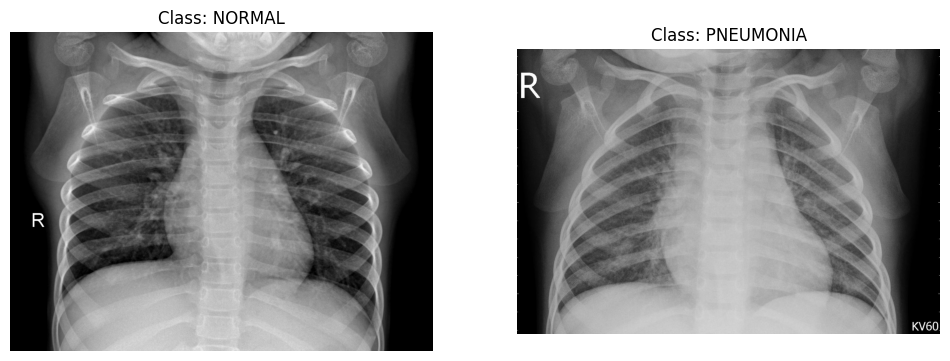

In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

def view_random_images(target_dir, target_class):
    # Setup target directory
    target_folder = os.path.join(target_dir, target_class)

    # Get a random image path
    random_image = random.sample(os.listdir(target_folder), 1)

    # Read and plot image
    img = mpimg.imread(os.path.join(target_folder, random_image[0]))
    plt.imshow(img, cmap='gray')
    plt.title(f"Class: {target_class}")
    plt.axis("off")
    print(f"Image shape: {img.shape}")
    return img

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
view_random_images(train_path, "NORMAL")
plt.subplot(1, 2, 2)
view_random_images(train_path, "PNEUMONIA")
plt.show()

## Data Preprocessing & Augmentation
Here, we construct the `ImageDataGenerator` objects.
* **Data Augmentation:** Applied only to the training set (rotation, zoom, shifts) to artificially expand the dataset and prevent overfitting. Horizontal flipping is disabled to maintain true anatomical orientation.
* **Normalisation:** We strictly utilise `tf.keras.applications.densenet.preprocess_input` instead of standard rescaling to ensure the pixel values exactly match the distribution DenseNet was originally trained on.

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.densenet import preprocess_input

IMAGE_SIZE = (150, 150)
BATCH_SIZE = 32
SEED_VAL = 42

#TRAIN_DIR = '/kaggle/input/chest-xray-pneumonia/chest_xray/train'
#TEST_DIR = '/kaggle/input/chest-xray-pneumonia/chest_xray/test'

def create_generators():
    print("Initializing DenseNet-Optimized Data Generators...")

    # 1. Training Augmentation (Replace rescale with preprocessing_function)
    train_processor = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=20,
        width_shift_range=0.1,
        height_shift_range=0.1,
        shear_range=0.1,
        zoom_range=0.2,
        horizontal_flip=False,
        validation_split=0.2
    )

    # 2. Validation Processor (Must also use the specific preprocessor)
    val_processor = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        validation_split=0.2
    )

    # 3. Test Processor
    test_processor = ImageDataGenerator(
        preprocessing_function=preprocess_input
    )

    # --- GENERATOR FLOWS ---
    train_gen = train_processor.flow_from_directory(
        TRAIN_DIR,
        target_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        subset='training',
        seed=SEED_VAL,
        shuffle=True
    )

    val_gen = val_processor.flow_from_directory(
        TRAIN_DIR,
        target_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        subset='validation',
        seed=SEED_VAL,
        shuffle=False
    )

    test_gen = test_processor.flow_from_directory(
        TEST_DIR,
        target_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=False
    )

    return train_gen, val_gen, test_gen

# Execute the function to load the data into memory
train_gen, val_gen, test_gen = create_generators()

Initializing DenseNet-Optimized Data Generators...
Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


## Model Evaluation and Decision Threshold Calibration
This section evaluates the generalisation capability of the trained network against the strictly unseen test dataset. The `evaluate_model` function acts as a universal diagnostic tool, generating a comprehensive suite of clinical performance metrics:

* **Learning Curves:** Visualises epoch-by-epoch training versus validation loss and accuracy to empirically verify the stability of the model and the absence of overfitting.
* **Confusion Matrix:** A Seaborn-generated cross-tabulation of True Positives, True Negatives, False Positives, and False Negatives to expose any residual class bias.
* **Classification Report & Calibration:** Calculates precision, recall, and F1-scores. Crucially, the model's probabilistic outputs are evaluated across variable decision thresholds (e.g., $0.4$ to $0.7$) to establish the mathematically optimal trade-off between clinical sensitivity (detecting all pneumonia cases) and specificity (minimising false alarms).

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def evaluate_model(model, name, history, test_gen):
    print(f"\n Evaluating Model: {name}")

    # 1. Plot Trends using the history object
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Val')
    plt.title(f'{name} Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.title(f'{name} Loss')
    plt.legend()
    plt.show()

    # 2. Test Evaluation
    # Get true labels directly from the generator property
    y_true = test_gen.classes

    # CRITICAL: Reset the generator before predicting so order matches exactly
    test_gen.reset()
    y_pred = (model.predict(test_gen) > 0.5).astype("int32")

    print(f"\n {name} Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))

    # 3. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
    plt.title(f'{name} Confusion Matrix')
    plt.show()

## Model Architecture Construction
This function constructs a composite Transfer Learning model:
* **Base Model:** `DenseNet121` (weights initially frozen to preserve ImageNet feature extractors).
* **Classification Head:** A custom architecture featuring Global Average Pooling, a Dense layer protected by a relaxed **L2 Regularisation** ($10^{-4}$) to capture fine radiographic textures, and heavy **Dropout** ($0.5$) to physically prevent the memorisation of training artifacts.





In [ ]:
from tensorflow.keras import layers, models, regularizers, optimizers
import tensorflow as tf

def build_expert_densenet(dropout_rate=0.5):
    print("Building Expert DenseNet121...")
    base_model = tf.keras.applications.DenseNet121(
        weights='imagenet', include_top=False, input_shape=(150, 150, 3)
    )
    base_model.trainable = False

    model = models.Sequential(name="DenseNet_Expert")
    model.add(base_model)
    model.add(layers.GlobalAveragePooling2D())

    #Relaxed L2 to 1e-4 so the model can learn finer textures
    model.add(layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(1, activation='sigmoid'))

    return model, base_model

## 3. Stage 1: Classifier Head Training
In the first phase of training, the DenseNet base remains entirely frozen. The objective is to map the pre-learned feature vectors to our specific clinical outcomes. 
* **Callbacks:** `ReduceLROnPlateau` acts as a dynamic braking system (factor of $0.3$) to prevent volatile validation loss spikes, paired with **Early Stopping** (patience of 6 epochs) to automatically halt training and restore the best weights if the model stops improving.
* **Class Weights:** Algorithmic balancing (Normal: $1.94$, Pneumonia: $0.67$) is applied to heavily penalise the network for missing the minority class (Normal) images, specifically forcing the model to reduce False Positives.

In [ ]:
def train_stage_1(model, train_gen, val_gen):
    print("\n--- STAGE 1: Training the Head ---")
    model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                  loss='binary_crossentropy', metrics=['accuracy'])

    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6, verbose=1
    )
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=6, restore_best_weights=True
    )

    # Balances the 0.74 vs 0.97 Recall issue
    class_weight = {0: 1.94, 1: 0.67}

    history = model.fit(
        train_gen, validation_data=val_gen, epochs=15,
        class_weight=class_weight, callbacks=[early_stop, reduce_lr]
    )
    return history

## 4. Stage 2: Semantic Block Fine-Tuning
Once the classification head is stable, we mathematically unfreeze the entire final Dense Block of the network (beginning at `conv5_block1_0_bn`). 
* **Micro-Learning Rate:** We reduce the optimiser's learning rate to $10^{-5}$. This ensures we delicately adapt the high-level semantic convolutional filters to recognise specific pulmonary opacities without aggressively destroying the pre-trained weights (preventing catastrophic forgetting).
* **Early Stopping:** Monitored with a patience of 5 epochs to prevent over-adaptation to the training set.

In [ ]:
def train_expert_finetuning(model, base_model, train_gen, val_gen):
    print("\n--- EXPERT STAGE 2: Semantic Block Fine-Tuning ---")

    base_model.trainable = True

    # Unfreeze the ENTIRE final Dense Block mathematically, not arbitrarily
    set_trainable = False
    for layer in base_model.layers:
        if layer.name == 'conv5_block1_0_bn': # The exact start of Dense Block 5
            set_trainable = True

        if set_trainable:
            layer.trainable = True
        else:
            layer.trainable = False

    # Compile with a very low learning rate
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-5),
                  loss='binary_crossentropy', metrics=['accuracy'])

    # We can afford more patience now because we are fine-tuning a whole block
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True
    )

    history_fine = model.fit(
        train_gen, validation_data=val_gen, epochs=15,
        callbacks=[early_stop]
    )
    return history_fine

### Evaluation and Export
Finally, we evaluate the model against the unseen test dataset. The generator is explicitly reset before prediction to ensure label alignment. Upon successful evaluation, the dual-stage trained model is compiled into a single `.keras` file for future deployment.

Initializing DenseNet-Optimized Data Generators...
Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Building Expert DenseNet121...

--- STAGE 1: Training the Head ---
Epoch 1/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 195s 1s/step - accuracy: 0.8548 - loss: 0.3897 - val_accuracy: 0.8744 - val_loss: 0.3651 - learning_rate: 0.0010
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 222s 2s/step - accuracy: 0.9032 - loss: 0.2392 - val_accuracy: 0.8504 - val_loss: 0.4049 - learning_rate: 0.0010
Epoch 3/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9058 - loss: 0.2428
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
131/131 ━━━━━━━━━━━━━━━━━━━━ 238s 2s/step - accuracy: 0.9145 - loss: 0.2342 - val_accuracy: 0.8102 - val_loss: 0.4932 - learning_rate: 0.0010
Epoch 4/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 235s 2s/step - accuracy: 0.9327 - loss: 0.1927 - val_accuracy: 0.8859 - val_loss: 0.3202 - learning_rate: 3.

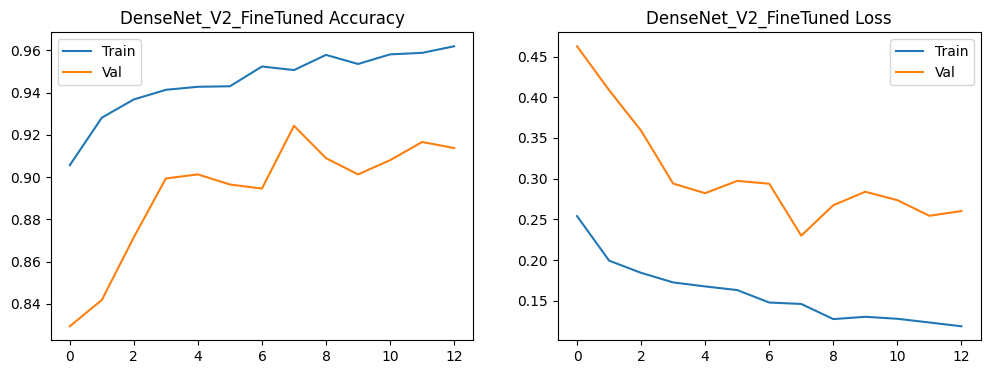

20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 887ms/step

 DenseNet_V2_FineTuned Classification Report:
              precision    recall  f1-score   support

      Normal       0.92      0.85      0.88       234
   Pneumonia       0.92      0.95      0.93       390

    accuracy                           0.92       624
   macro avg       0.92      0.90      0.91       624
weighted avg       0.92      0.92      0.92       624



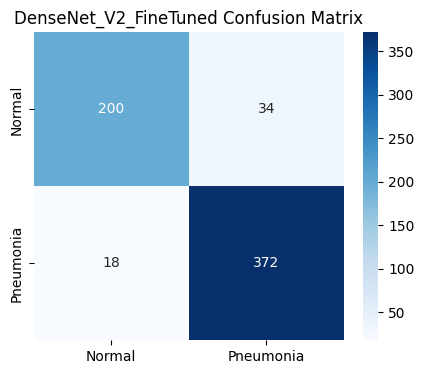

In [14]:
import numpy as np
from sklearn.metrics import classification_report


train_gen, val_gen, test_gen = create_generators()

# 1. Build & Train
expert_model, expert_base = build_expert_densenet(dropout_rate=0.5)

# (Uses your existing Stage 1 function)
history_1 = train_stage_1(expert_model, train_gen, val_gen)

# Semantic Fine-Tuning
history_2 = train_expert_finetuning(expert_model, expert_base, train_gen, val_gen)

# 2. Production Evaluation
print("\n--- EXPERT THRESHOLD CALIBRATION ---")
y_true = test_gen.classes
test_gen.reset()
y_probabilities = expert_model.predict(test_gen)

# Test multiple clinical thresholds
thresholds = [0.4, 0.5, 0.6, 0.7]

for t in thresholds:
    print(f"\nEvaluating Threshold: {t}")
    y_pred_t = (y_probabilities > t).astype("int32")
    report = classification_report(y_true, y_pred_t, target_names=['Normal', 'Pneumonia'], output_dict=True)

    # Extracting F1 scores for a clean readout
    f1_normal = report['Normal']['f1-score']
    f1_pneumonia = report['Pneumonia']['f1-score']
    acc = report['accuracy']

    print(f"Accuracy: {acc:.2f} | F1 Normal: {f1_normal:.2f} | F1 Pneumonia: {f1_pneumonia:.2f}")


evaluate_model(expert_model, "DenseNet_V2_FineTuned", history_2, test_gen)

# 3. Save the final production model
expert_model.save('pneumonia_prediction.keras')

Loading the generated model and evaluating it

Loading Production Model...

--- MODEL ARCHITECTURE SUMMARY ---


Model: "DenseNet_Expert"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 4, 4, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,145,733 (46.33 MB)

 Trainable params: 2,422,785 (9.24 MB)

 Non-trainable params: 4,877,376 (18.61 MB)

 Optimizer params: 4,845,572 (18.48 MB)


Generating Clinical Predictions...
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 825ms/step

--- FINAL CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

      Normal       0.92      0.85      0.88       234
   Pneumonia       0.92      0.95      0.93       390

    accuracy                           0.92       624
   macro avg       0.92      0.90      0.91       624
weighted avg       0.92      0.92      0.92       624



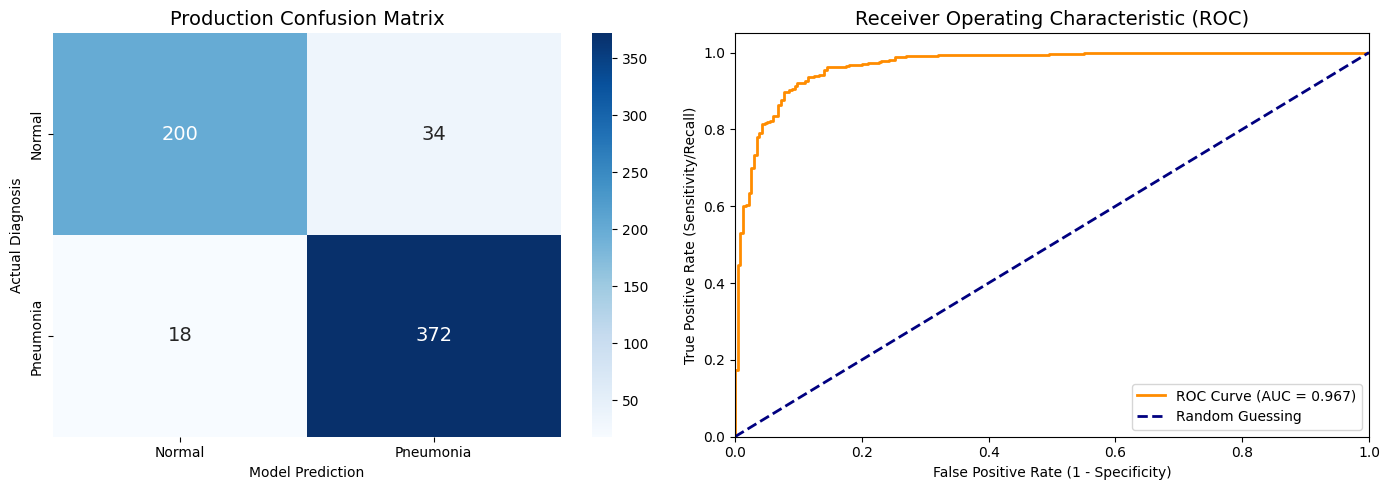

In [15]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# 1. Load the Exported Model
print("Loading Production Model...")
loaded_expert_model = tf.keras.models.load_model('pneumonia_prediction.keras')

# 2. Display Model Summary
print("\n--- MODEL ARCHITECTURE SUMMARY ---")
loaded_expert_model.summary()

# 3. Generate Predictions on the Test Set
print("\nGenerating Clinical Predictions...")
test_gen.reset() # CRITICAL: Always reset before predicting!
y_true = test_gen.classes
y_probabilities = loaded_expert_model.predict(test_gen)

# Using 0.5 as your calibration showed it yielded 91% accuracy
OPTIMAL_THRESHOLD = 0.5
y_pred = (y_probabilities > OPTIMAL_THRESHOLD).astype("int32")

# 4. Print Classification Report
print("\n--- FINAL CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))

# --- PLOTTING SUITE ---
plt.figure(figsize=(14, 5))

# Plot 1: Confusion Matrix
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'],
            annot_kws={"size": 14})
plt.title('Production Confusion Matrix', fontsize=14)
plt.ylabel('Actual Diagnosis')
plt.xlabel('Model Prediction')

# Plot 2: ROC Curve & AUC (Area Under the Curve)
plt.subplot(1, 2, 2)
# Calculate the False Positive Rate (fpr) and True Positive Rate (tpr)
fpr, tpr, _ = roc_curve(y_true, y_probabilities)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity/Recall)')
plt.title('Receiver Operating Characteristic (ROC)', fontsize=14)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

## Explainable AI (XAI): Focused Grad-CAM Visualisation
To establish clinical trust and empirically verify that the network is identifying genuine pulmonary opacities rather than exploiting background artifacts (such as mediastinal shadows), this section implements **Gradient-weighted Class Activation Mapping (Grad-CAM)**. 

Using `tf.GradientTape`, the function extracts the spatial gradients flowing into the final convolutional block of the DenseNet base. To ensure the output meets clinical readability standards, the raw heatmaps undergo rigorous algorithmic post-processing:
* **Strict Thresholding:** The bottom 70% of 'lukewarm' activations are mathematically truncated. This active zeroing eliminates diffuse noise and central-chest bias, forcing the output to pinpoint highly specific focal lesions.
* **Clinical Overlay:** The standard 'jet' colormap is discarded to prevent the introduction of false diagnostic boundaries. Instead, the focal map is projected as a pure red overlay, scaling transparency directly with the thresholded activation intensity for seamless integration with grayscale radiography.

Generating Focused Grad-CAM for 5 random test images...


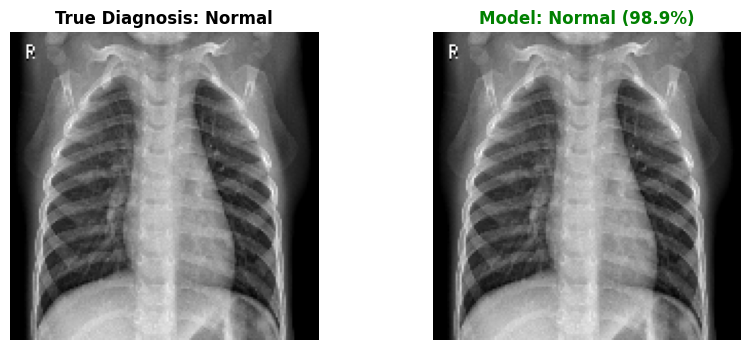

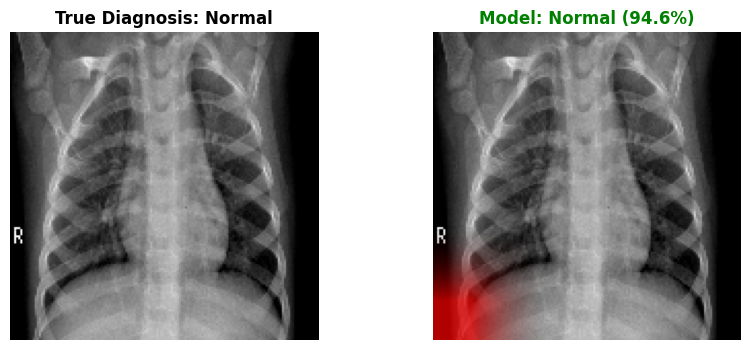

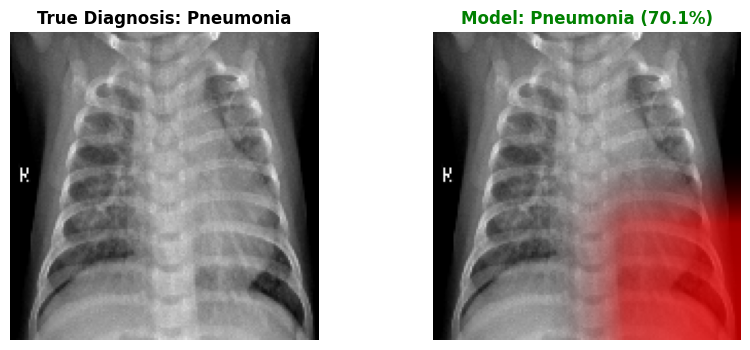

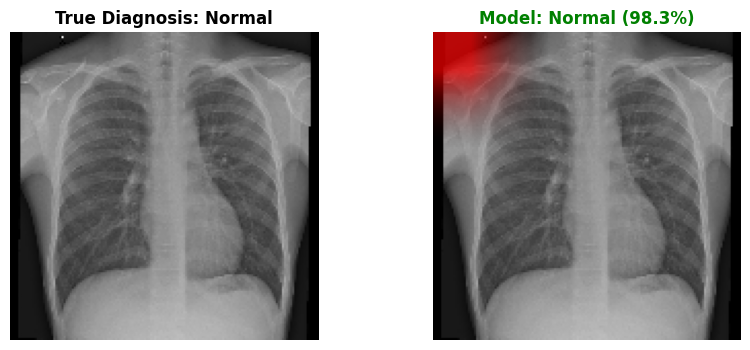

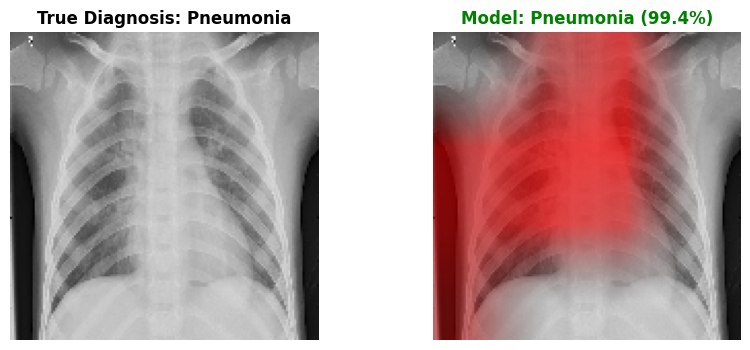

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import random

def generate_focused_gradcam(model, test_gen, num_images=5):
    print(f"Generating Focused Grad-CAM for {num_images} random test images...")
    
    # Extract layers
    base_model = model.layers[0]
    gap_layer = model.layers[1]
    dense_1 = model.layers[2]
    dropout = model.layers[3]
    prediction_layer = model.layers[4]

    random_indices = random.sample(range(test_gen.samples), num_images)

    for idx in random_indices:
        img_path = test_gen.filepaths[idx]
        true_label = "Pneumonia" if test_gen.classes[idx] == 1 else "Normal"
        
        raw_img = tf.keras.utils.load_img(img_path, target_size=(150, 150))
        raw_img_array = tf.keras.utils.img_to_array(raw_img)
        
        model_input = tf.keras.applications.densenet.preprocess_input(
            np.expand_dims(raw_img_array.copy(), axis=0)
        )

        with tf.GradientTape() as tape:
            conv_outputs = base_model(model_input)
            tape.watch(conv_outputs) 
            
            x = gap_layer(conv_outputs)
            x = dense_1(x)
            x = dropout(x, training=False) 
            preds = prediction_layer(x)
            class_channel = preds[:, 0]

        grads = tape.gradient(class_channel, conv_outputs)
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

        conv_outputs = conv_outputs[0]
        heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
        heatmap = tf.squeeze(heatmap)

        heatmap = tf.maximum(heatmap, 0) # Keep only positive gradients
        
        # Calculate the top 70% threshold. We ONLY keep the strongest 30% of the signal.
        threshold = 0.7 * tf.math.reduce_max(heatmap)
        heatmap = tf.where(heatmap < threshold, 0.0, heatmap) # Zero out the diffuse noise

        # Normalise
        max_heat = tf.math.reduce_max(heatmap)
        if max_heat != 0:
            heatmap /= max_heat
        heatmap = heatmap.numpy()

        # Resize to 150x150
        heatmap_resized = tf.image.resize(heatmap[..., tf.newaxis], (150, 150)).numpy()
        heatmap_resized = np.squeeze(heatmap_resized)

        # Create RGBA mapping (Pure Red with variable transparency)
        heatmap_rgba = np.zeros((150, 150, 4))
        heatmap_rgba[..., 0] = heatmap_resized       # Red channel intensity
        heatmap_rgba[..., 3] = heatmap_resized * 0.7 # Alpha (Transparency) - max 70% opacity

        pred_val = preds[0][0].numpy()
        pred_label = "Pneumonia" if pred_val > 0.5 else "Normal"
        confidence = pred_val * 100 if pred_val > 0.5 else (1 - pred_val) * 100

        # Plotting
        plt.figure(figsize=(10, 4))
        
        plt.subplot(1, 2, 1)
        plt.imshow(raw_img_array / 255.0, cmap='gray')
        plt.title(f"True Diagnosis: {true_label}", fontweight='bold')
        plt.axis('off')
        
        plt.subplot(1, 2, 2)
        plt.imshow(raw_img_array / 255.0, cmap='gray') # Draw X-ray first
        plt.imshow(heatmap_rgba)                       # Draw pure red thresholded heatmap on top
        
        title_color = 'green' if pred_label == true_label else 'red'
        plt.title(f"Model: {pred_label} ({confidence:.1f}%)", color=title_color, fontweight='bold')
        plt.axis('off')
        
        plt.show()

# Run the updated function
loaded_model = tf.keras.models.load_model("pneumonia_prediction.keras")
generate_focused_gradcam(loaded_model, test_gen, num_images=5)